In [1]:
# =========================
# IMPORTY
# =========================
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error

import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# =========================
# WCZYTANIE DANYCH
# =========================
df = pd.read_csv("vlagunr-Phyto.csv")
print(df.head())

     PSU     O2  temp.   SRP   DOP     PP   NH4N   NO3N    DON     PN   TN/TP  \
0  3.758   9.46   18.3   3.5  11.7  185.0  0.039  0.022  0.551  0.759   6.848   
1  3.505   9.89   19.1   4.4  17.5  111.3  0.020  0.025  0.123  1.181  10.128   
2  3.758   9.66   18.1   3.2  22.8  103.4  0.016  0.008  0.582  0.576   9.134   
3  3.107  10.36   19.5   4.3  22.3   92.7  0.026  0.021  0.693  0.689  11.978   
4  2.619  11.56   19.0  11.7  30.3   73.2  0.022  0.048  0.383  1.006  12.665   

      Fe  SiO4Si  Windspeedinsitu  Depth  DIN to DIP  PhytoBiomassC  
0  0.012   2.311              3.5    3.3      17.429          1.757  
1  0.014   2.116              0.0    3.6      10.227          2.147  
2  0.037   2.264              1.0    3.4       7.500          2.604  
3  0.017   2.262              0.0    2.9      10.930          2.062  
4  0.024   2.216              0.0    3.0       5.983          2.085  


In [4]:
# =========================
# DEFINICJA ZMIENNYCH
# =========================
y = df["PhytoBiomassC"]
X = df.drop(columns=["PhytoBiomassC"])


In [5]:
# =========================
# PODZIAŁ DANYCH
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# =========================
# BASELINE MODEL (PRZED CV)
# =========================
baseline_model = XGBRegressor()
baseline_model.fit(X_train, y_train)

y_train_pred_base = baseline_model.predict(X_train)
y_test_pred_base = baseline_model.predict(X_test)

print("=== BASELINE MODEL (PRZED CV) ===")
print("Train R2:", r2_score(y_train, y_train_pred_base))
print("Test R2:", r2_score(y_test, y_test_pred_base))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_base)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_base)))


=== BASELINE MODEL (PRZED CV) ===
Train R2: 0.9999995215237034
Test R2: 0.25848800225653235
Train RMSE: 0.0006317858480011073
Test RMSE: 0.6567898987070693


In [7]:
# =========================
# RANDOM GRID
# =========================
random_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [8]:
# =========================
# MODEL + CV
# =========================
model = XGBRegressor()

model_random = RandomizedSearchCV(
    estimator=model,
    param_distributions=random_grid,
    n_iter=50,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

model_random.fit(X_train, y_train)
best_model = model_random.best_estimator_

print("Najlepsze parametry:", model_random.best_params_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Najlepsze parametry: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [9]:
# =========================
# EWALUACJA PO CV (TRAIN + TEST)
# =========================
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

print("\n=== MODEL PO CV ===")
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))


=== MODEL PO CV ===
Train R2: 0.739588966916982
Test R2: 0.42432480109266557
Train RMSE: 0.46608955408217684
Test RMSE: 0.5787035326312767


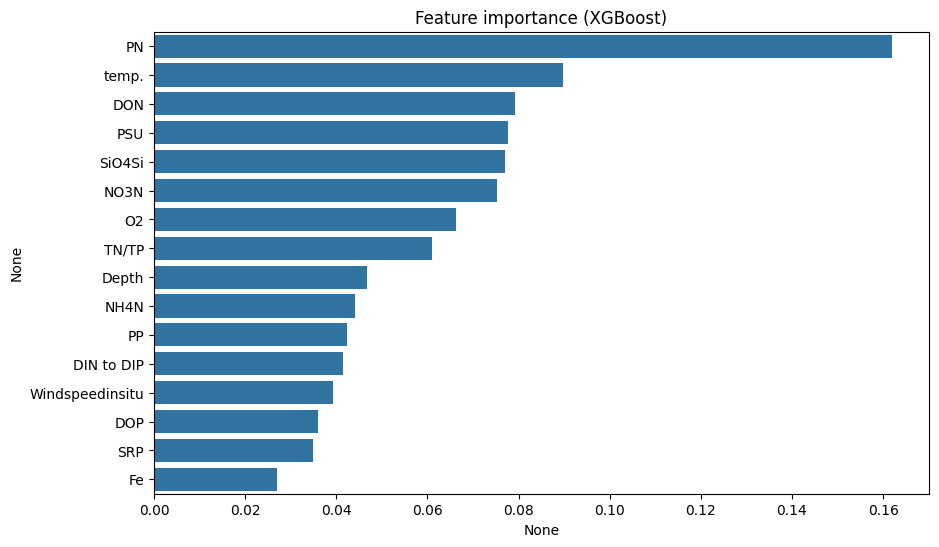

In [10]:
# =========================
# FEATURE IMPORTANCE
# =========================
importances = best_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Feature importance (XGBoost)")
plt.show()

In [13]:
# =========================
# SHAP
# =========================
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)


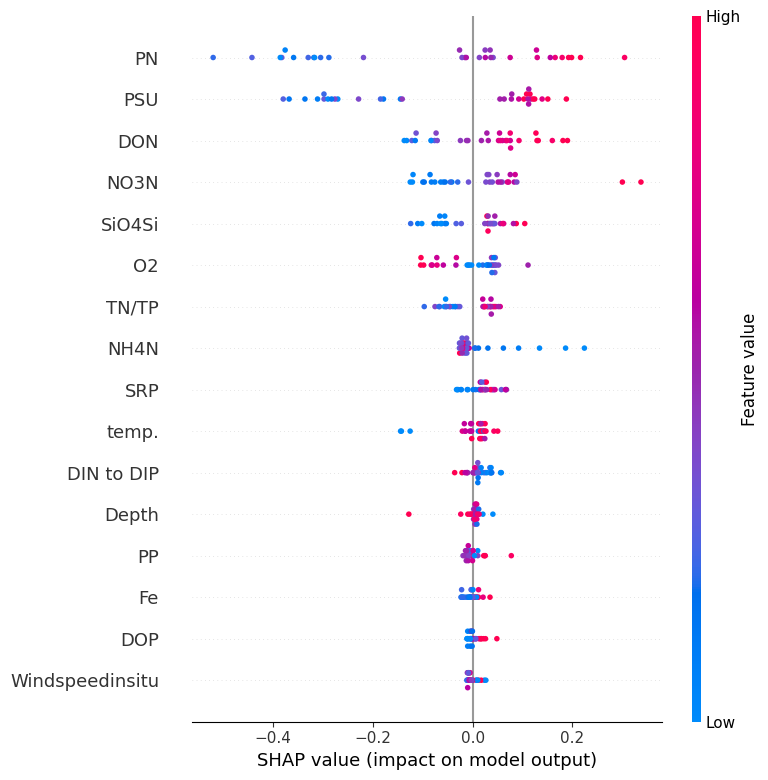

In [14]:
# Summary plot
shap.summary_plot(shap_values, X_test)


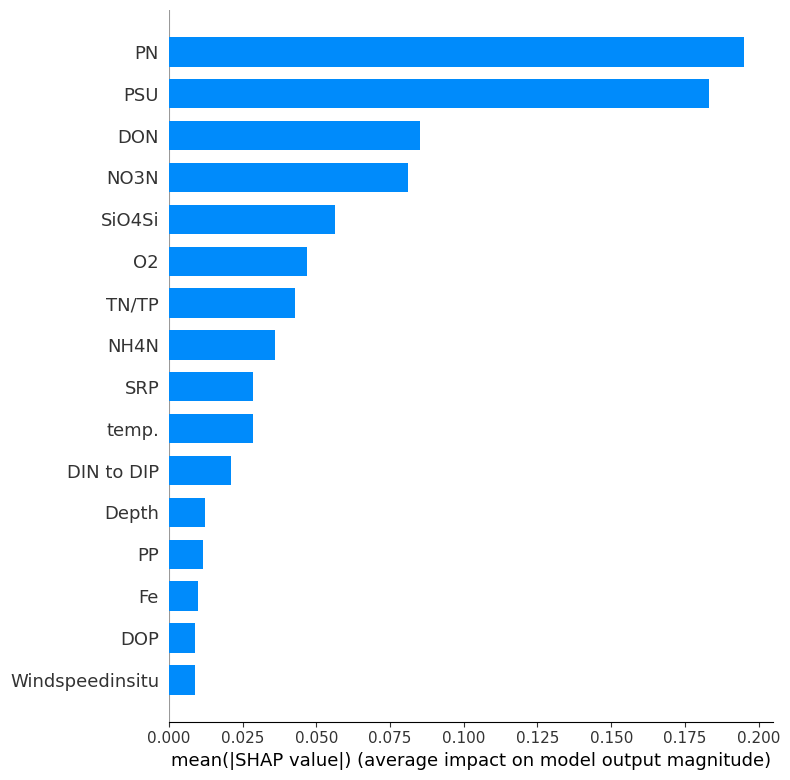

In [15]:
# Bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

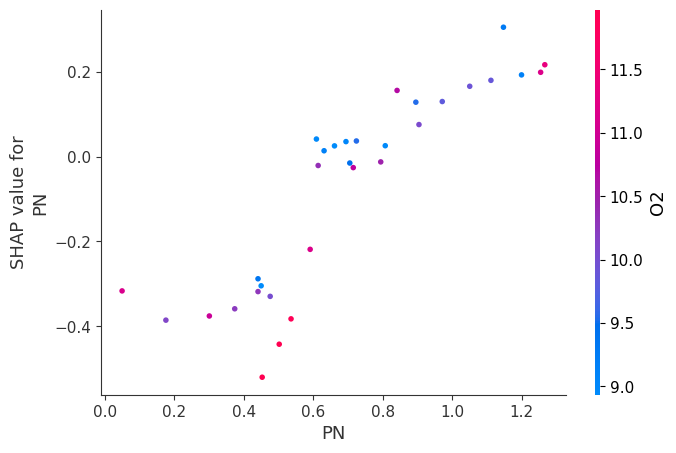

In [16]:
# Dependence plot
top_feature = feat_imp.index[0]
shap.dependence_plot(top_feature, shap_values, X_test)

In [17]:
# =========================
# WARTOŚCI SHAP
# =========================
shap_df = pd.DataFrame(shap_values, columns=X.columns)
print(shap_df.head())

        PSU        O2     temp.       SRP       DOP        PP      NH4N  \
0 -0.141068  0.111132 -0.002297  0.025863  0.025896  0.010313 -0.011885   
1  0.108279  0.045464  0.021412  0.019081 -0.004056  0.025353 -0.020811   
2 -0.367823 -0.103481 -0.142704 -0.028922  0.006514 -0.007057  0.011726   
3 -0.310831 -0.098139 -0.125214 -0.032254 -0.009842  0.001099 -0.026515   
4 -0.270246  0.051992  0.016566  0.065742 -0.001355 -0.008290 -0.021761   

       NO3N       DON        PN     TN/TP        Fe    SiO4Si  \
0 -0.063905 -0.115001 -0.012677  0.043549  0.011853 -0.055843   
1  0.083343  0.093041  0.165511 -0.066048 -0.002891  0.104566   
2  0.029242 -0.009387 -0.520086  0.022311 -0.021443  0.028772   
3 -0.058675 -0.076159 -0.382529 -0.035294 -0.022320  0.029988   
4 -0.054965  0.053998 -0.385590 -0.029391 -0.018544  0.031112   

   Windspeedinsitu     Depth  DIN to DIP  
0        -0.009781 -0.005414    0.037474  
1        -0.009578  0.012558    0.011111  
2         0.023479  0.003267 


=== ABS_SHAP (Mean |SHAP|) ===
   feature  mean_abs_shap
9       PN       0.194970
0      PSU       0.182995
8      DON       0.085129
7     NO3N       0.081172
12  SiO4Si       0.056435


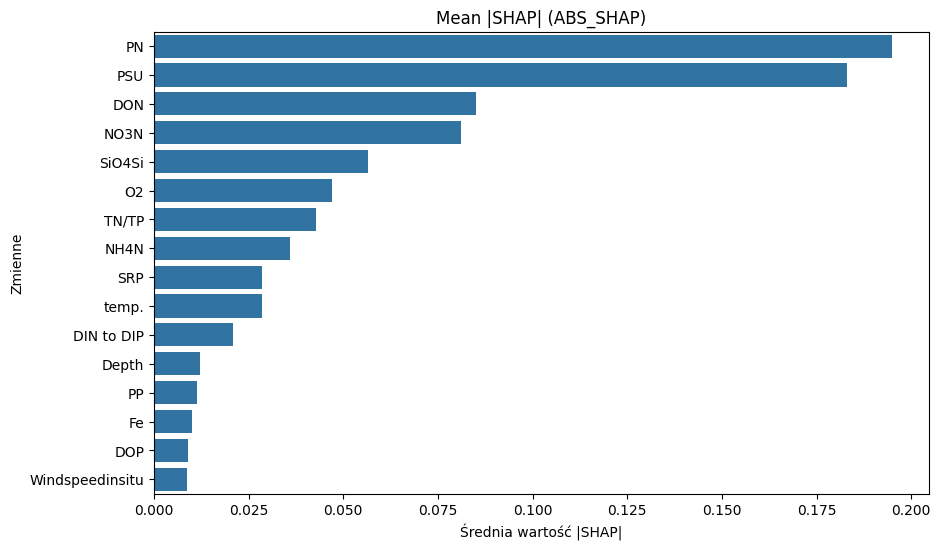

In [18]:
# =========================
# ABS_SHAP
# =========================
abs_shap_values = np.abs(shap_values)
mean_abs_shap = np.mean(abs_shap_values, axis=0)

abs_shap_df = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False)

print("\n=== ABS_SHAP (Mean |SHAP|) ===")
print(abs_shap_df.head())

# Wykres
plt.figure(figsize=(10,6))
sns.barplot(
    x=abs_shap_df["mean_abs_shap"],
    y=abs_shap_df["feature"]
)
plt.title("Mean |SHAP| (ABS_SHAP)")
plt.xlabel("Średnia wartość |SHAP|")
plt.ylabel("Zmienne")
plt.show()

In [19]:
# =========================
# ITERACJE
# =========================
results = []

for i in range(5):
    model_random = RandomizedSearchCV(
        estimator=XGBRegressor(),
        param_distributions=random_grid,
        n_iter=30,
        cv=3,
        random_state=i,
        n_jobs=-1
    )

    model_random.fit(X_train, y_train)
    y_pred = model_random.best_estimator_.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results.append(r2)

print("\nŚrednie R2 z iteracji:", np.mean(results))


Średnie R2 z iteracji: 0.3583647280202002
